# Lesson 5.4 — Singularity Loci and Workspace Boundaries
**Module 6 · Unit 5 · Lesson 20**

The singularity locus is {q : w(q)=0}. For the planar 2R it is θ₂ = 0, π — tracing the outer (L₁+L₂) and inner (|L₁−L₂|) workspace circles. M5's "recognize det J=0" becomes full theory.

In [1]:
import numpy as np
def dh(th,d,a,al):
    ct,st,ca,sa=np.cos(th),np.sin(th),np.cos(al),np.sin(al)
    return np.array([[ct,-st*ca,st*sa,a*ct],[st,ct*ca,-ct*sa,a*st],[0,sa,ca,d],[0,0,0,1]])
def forward_chain(P,T,q):
    M=np.eye(4); Ms=[M.copy()]
    for i,(th0,d0,a,al) in enumerate(P):
        th,d=(th0+q[i],d0) if T[i]=="R" else (th0,d0+q[i]); M=M@dh(th,d,a,al); Ms.append(M.copy())
    return Ms
def geometric_jacobian(P,T,q):
    Ms=forward_chain(P,T,q); on=Ms[-1][:3,3]; J=np.zeros((6,len(q)))
    for i in range(len(q)):
        z=Ms[i][:3,2]; o=Ms[i][:3,3]
        if T[i]=="R": J[:3,i]=np.cross(z,on-o); J[3:,i]=z
        else: J[:3,i]=z
    return J
def Jv_planar(P,T,q): return geometric_jacobian(P,T,q)[:2,:]
def reach(P,T,q):
    M=forward_chain(P,T,q)[-1]; return float(np.hypot(M[0,3],M[1,3]))
P2=[(0,0,1.0,0),(0,0,1.0,0)]; T2=["R","R"]            # planar 2R, L1=L2=1


## Map w(θ₂): zeros at θ₂ = 0, π define the locus

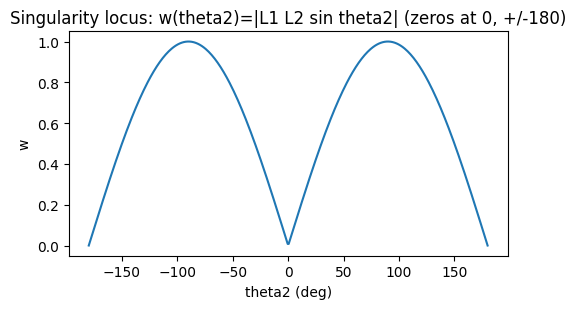

In [2]:
checks=[]
import matplotlib.pyplot as plt
def w(q):
    J=Jv_planar(P2,T2,q); return float(np.prod(np.linalg.svd(J,compute_uv=False)))
t2=np.linspace(-np.pi,np.pi,400); wv=[w(np.array([0.3,t])) for t in t2]
plt.figure(figsize=(5.2,3.2)); plt.plot(np.degrees(t2),wv); plt.xlabel('theta2 (deg)'); plt.ylabel('w')
plt.title('Singularity locus: w(theta2)=|L1 L2 sin theta2| (zeros at 0, +/-180)'); plt.tight_layout(); plt.show()
checks.append(w(np.array([0.3,0.0]))<1e-9 and w(np.array([0.3,np.pi]))<1e-9 and abs(max(wv)-1.0)<1e-2)

## Singular angles map to the workspace boundary circles

In [3]:
print("theta2=0   -> reach",round(reach(P2,T2,np.array([0.3,0.0])),3),"= L1+L2 (outer circle)")
print("theta2=pi  -> reach",round(reach(P2,T2,np.array([0.3,np.pi])),3),"= |L1-L2| (inner circle)")
checks.append(np.isclose(reach(P2,T2,np.array([0.3,0.0])),2.0))
checks.append(np.isclose(reach(P2,T2,np.array([0.3,np.pi])),0.0,atol=1e-6))

theta2=0   -> reach 2.0 = L1+L2 (outer circle)
theta2=pi  -> reach 0.0 = |L1-L2| (inner circle)


## No interior singularities for the simple 2R (locus is the boundary only)

In [4]:
interior=[w(np.array([0.3,t])) for t in np.linspace(0.3,np.pi-0.3,50)]
print("min w over interior theta2 in (0,pi):",round(min(interior),4),"(> 0 -> no internal singularity)")
checks.append(min(interior)>1e-3)
assert all(checks), f"FAILED: {checks}"
print("All checks passed.")

min w over interior theta2 in (0,pi): 0.2955 (> 0 -> no internal singularity)
All checks passed.
